# The Expanding Universe

**Third-Year Research Project — Cosmology**

**Fiducial parameters** (given in brief): $H_0 = 67.4\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$,
$\Omega_{m,0}=0.3$, $\Omega_{\Lambda,0}=0.7$.

**Sections**
1. Imports, constants and units
2. The dimensionless Friedmann equation and ODE solver
3. Analytic solutions (for validation)
4. Solving and validating $a(t)$ for matter-only, radiation-only, and $\Lambda$CDM
5. Plot: $a(t)$ vs cosmic time (numerical + analytic overlay)
6. Plot: $H(z)$ vs redshift
7. Cosmological distances and the distance modulus
8. Plot: distance modulus $\mu(z)$
9. Parameter sweep over $\Omega_{m,0}$
10. Cosmographic Taylor expansion check
11. Numerical precision check


## 1. Imports, constants and units

In [3]:
#Importing all necessary packages
import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.interpolate import InterpolatedUnivariateSpline
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100 #Dots per inch
plt.rcParams['font.size'] = 11 #Font size

#Physical constants and unit conversions
H0_kmsMpc = 67.4 #Hubble constant, km/s/Mpc
c_kms     = 299792.458 #Speed of light (km/s)
Mpc_km    = 3.0856775812799586e19 #km per Mpc (Megaparsec)
Gyr_s     = 3.1536e16 #seconds per Gyr (Gigayears)

H0 = (H0_kmsMpc / Mpc_km) * Gyr_s #H0 expressed in 1/Gyr
print(f"H0 = {H0_kmsMpc} km/s/Mpc  =  {H0:.6f} /Gyr   (Hubble time 1/H0 = {1/H0:.4f} Gyr)")

H0 = 67.4 km/s/Mpc  =  0.068884 /Gyr   (Hubble time 1/H0 = 14.5172 Gyr)


## 2. The dimensionless Friedmann equation and the ODE solver

From Part 2, for a flat universe the Friedmann equation can be written as
$$H^2(a) = H_0^2\, E^2(a), \qquad E^2(a) = \Omega_{m,0}\,a^{-3} + \Omega_{r,0}\,a^{-4} + \Omega_{\Lambda,0}.$$

Since $H \equiv \dot a/a$, this gives the first-order ODE required by the project brief:
$$\dot a = H_0\, a\, E(a).$$

Integrating exactly from $a=0$ is singular (the universe originates at a Big Bang, where
$\dot a \to \infty$), so we start the integration from a very small time $t_i \ll t_0$,
seeding $a(t_i)$ with the appropriate early-time analytic power law, and integrate
forward with `scipy.integrate.solve_ivp`. This sidesteps the singularity while still
recovering the entire expansion history to extremely high accuracy.

In [4]:
#Defining a function for E^2
def E_squared(a, O_m=0.0, O_r=0.0, O_l=0.0):
    #Dimensionless Hubble parameter squared (E^2(a) = H^2(a)/H0^2) (7)
    return O_m*a**-3 + O_r*a**-4 + O_l

#Defining a function for da/dt = H0 * a * E(a)
def friedmann_1st_ODE(t, a, O_m, O_r, O_l):
    #Getting a(t)
    a_t = a[0]
    return [H0 * a_t * np.sqrt(E_squared(a_t, O_m, O_r, O_l))]

#Defining a function to integrate the Friedmann equation and return a dense (t,a) grid plus the solver object
def solve_scale_factor(O_m, O_r, O_l, a_start, t_start, t_end, n_dense=4000): 
    #Storing the numerical solution and information about the integration
    sol = solve_ivp(friedmann_1st_ODE, [t_start, t_end], [a_start], args=(O_m, O_r, O_l), dense_output=True, rtol=1e-11, atol=1e-14
                    , max_step=(t_end - t_start)/500) #small relative, absolute tolerances and a small max integration step for better accuracy
    #Producing grid
    t_grid = np.linspace(t_start, t_end, n_dense)
    a_grid = sol.sol(t_grid)[0]
    return t_grid, a_grid, sol #Returning output as a grid

## 3. Analytic solutions (Part 3) — used to validate the numerics

* **Matter-only:** $a(t) \propto t^{2/3}$,  $\;t_0 = \dfrac{2}{3H_0}$
* **Radiation-only:** $a(t)\propto t^{1/2}$,  $\;t_0 = \dfrac{1}{2H_0}$
* **de Sitter:** $a(t) = a_{\rm ref}\, e^{H_\Lambda (t-t_{\rm ref})}$, $H_\Lambda = \sqrt{\frac{\Lambda c^2}{3}}$
  
* **Full flat $\Lambda$CDM:**
$$a(t) = \left(\frac{\Omega_{m,0}}{\Omega_{\Lambda,0}}\right)^{1/3}
  \sinh^{2/3}\!\left(\tfrac{3}{2}\sqrt{\Omega_{\Lambda,0}}\,H_0 t\right),\qquad
  t_0 = \frac{2}{3H_0\sqrt{\Omega_{\Lambda,0}}}\,\mathrm{arcsinh}\sqrt{\frac{\Omega_{\Lambda,0}}{\Omega_{m,0}}}.$$


In [5]:
#Functions for matter-only universe
def t0_matter():
    return 2/(3*H0)

def a_matter(t, t0):
    return (t/t0)**(2/3)

#Functions for radiation-only universe
def t0_radiation():
    return 1/(2*H0)

def a_radiation(t, t0):
    return (t/t0)**(1/2)

#Function for de Sitter universe
def a_deSitter(t, H_l, t_ref=0.0, a_ref=1.0):
    return a_ref*np.exp(H_l*(t - t_ref))

#Functions for a full Lambda CDM solution    
def t0_LCDM(O_m, O_l):
    #Age of a flat universe for matter + Lambda, reduces to the matter-only if O_l -> 0
    if O_l <= 1e-12:
        return t0_matter()
    return 2/(3*H0*np.sqrt(O_l)) * np.arcsinh(np.sqrt(O_l/O_m))

def a_LCDM(t, O_m, O_l):
    return (O_m/O_l)**(1/3) * np.sinh(1.5*np.sqrt(O_l)*H0*t)**(2/3)

## 4. Solving and validating the three expansion histories

We integrate the ODE numerically for the matter-only, radiation-only, and fiducial flat $\Lambda$CDM ($\Omega_{m,0}=0.3,\ \Omega_{\Lambda,0}=0.7$) cases, and compare directly against the analytic solutions.

In [6]:
#Establishing variables for a matter-only universe using predefined functions
t0_m = t0_matter()
t_i  = 1e-6*t0_m #Not starting exactly at 0 (Big bang)
a_i  = a_matter(t_i, t0_m)
t_m, a_m_num, _ = solve_scale_factor(1.0, 0.0, 0.0, a_i, t_i, 3*t0_m) #Calling function to retrieve (t, a)
a_m_an = a_matter(t_m, t0_m)
error_m = np.max(np.abs(a_m_num-a_m_an)/a_m_an) #Calculating maximum error

#Establishing variables for a radiation-only universe using predefined functions
t0_r = t0_radiation()
t_i  = 1e-6*t0_r #Not starting exactly at 0 (Big bang)
a_i  = a_radiation(t_i, t0_r)
t_r, a_r_num, _ = solve_scale_factor(0.0, 1.0, 0.0, a_i, t_i, 3*t0_r) #Calling function to retrieve (t, a)
a_r_an = a_radiation(t_r, t0_r)
error_r = np.max(np.abs(a_r_num-a_r_an)/a_r_an) #Calculating maximum error

#Establishing variables for a fiducial flat LCDM model using predefined functions
O_m0, O_l0 = 0.3, 0.7
t0_L = t0_LCDM(O_m0, O_l0)
t_i  = 1e-4 #Not starting exactly at 0 (Big bang)
a_i  = a_LCDM(t_i, O_m0, O_l0)
t_L, a_L_num, solL = solve_scale_factor(O_m0, 0.0, O_l0, a_i, t_i, 3*t0_L) #Calling function to retrieve (t, a)
a_L_an = a_LCDM(t_L, O_m0, O_l0)
error_l = np.max(np.abs(a_L_num-a_L_an)/a_L_an) #Calculating maximum error

#Printing ages of each universe and their maximum numerical errors
print(f"Ages of the universe:  matter-only = {t0_m:.4f} Gyr,  radiation-only = {t0_r:.4f} Gyr,  LCDM = {t0_L:.4f} Gyr")
print(f"Maximum relative error vs analytic:  matter-only = {error_m:.2e},  radiation-only = {error_r:.2e},  LCDM = {error_l:.2e}")

Ages of the universe:  matter-only = 9.6782 Gyr,  radiation-only = 7.2586 Gyr,  LCDM = 13.9961 Gyr
Maximum relative error vs analytic:  matter-only = 8.09e-11,  radiation-only = 1.46e-10,  LCDM = 7.78e-11


## 5. Plot (a): $a(t)$ vs cosmic time

Numerical solutions (solid) overlaid with the analytic solutions (dashed markers) for all three cases, each normalised such that $a=1$ at its own present time $t_0$.

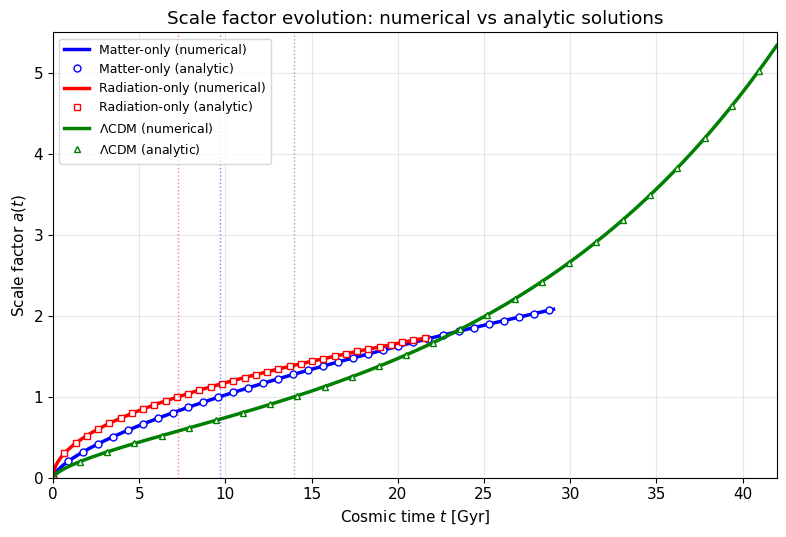

In [7]:
#Plotting our collected data
fig, ax = plt.subplots(figsize=(8,5.5))

#Matter-only plot
ax.plot(t_m, a_m_num, color='b', lw=2.5, label='Matter-only (numerical)')
ax.plot(t_m[::120], a_m_an[::120], 'o', color='b', ms=5, mfc='white',
        label='Matter-only (analytic)')

#Radiation-only plot
ax.plot(t_r, a_r_num, color='r', lw=2.5, label='Radiation-only (numerical)')
ax.plot(t_r[::120], a_r_an[::120], 's', color='r', ms=5, mfc='white',
        label='Radiation-only (analytic)')

#Lambda CDM plot
ax.plot(t_L, a_L_num, color='g', lw=2.5, label=r'$\Lambda$CDM (numerical)')
ax.plot(t_L[::150], a_L_an[::150], '^', color='g', ms=5, mfc='white',
        label=r'$\Lambda$CDM (analytic)')

#Where each model falls today
ax.axvline(t0_m, color='b', ls=':', lw=1, alpha=0.5)
ax.axvline(t0_r, color='r', ls=':', lw=1, alpha=0.5)
ax.axvline(t0_L, color='g', ls=':', lw=1, alpha=0.5)

#Labeling and displaying plot
ax.set_xlabel('Cosmic time $t$ [Gyr]')
ax.set_ylabel('Scale factor $a(t)$')
ax.set_title('Scale factor evolution: numerical vs analytic solutions')
ax.set_xlim(0, 42)
ax.set_ylim(0, 5.5)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Plot (b): $H(z)$ vs redshift

$H(z)$ follows directly from $E^2$ using $1+z = 1/a$:
$$H(z) = H_0\sqrt{\Omega_{m,0}(1+z)^3 + \Omega_{r,0}(1+z)^4 + \Omega_{\Lambda,0}}.$$

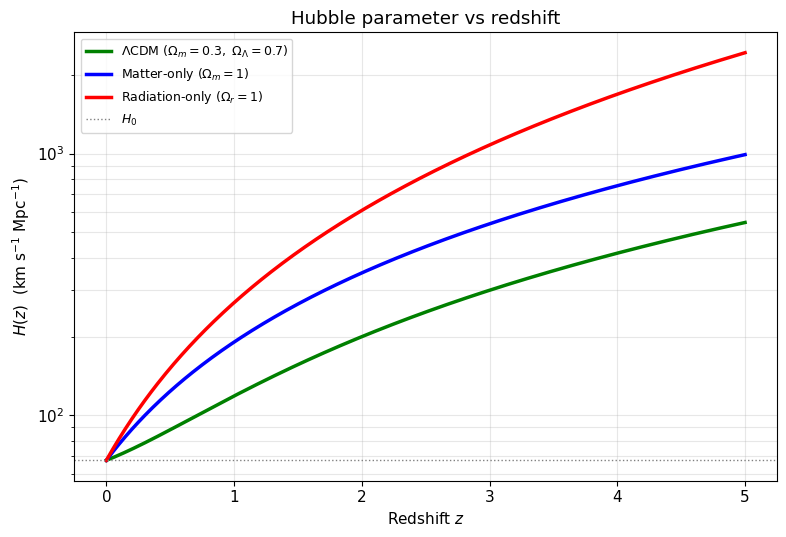

In [42]:
#Defining a function for H in terms of z (redshift)
def H_of_z(z, O_m, O_r, O_l):
    return H0_kmsMpc*np.sqrt(O_m*(1+z)**3 + O_r*(1+z)**4 + O_l)

#Defining spacing for smoothness
z_arr = np.linspace(0, 5, 400)

#Plotting our collected data
fig, ax = plt.subplots(figsize=(8,5.5))
ax.plot(z_arr, H_of_z(z_arr, 0.3, 0.0, 0.7), color='g', lw=2.5, label=r'$\Lambda$CDM ($\Omega_m=0.3,\ \Omega_\Lambda=0.7$)')
ax.plot(z_arr, H_of_z(z_arr, 1.0, 0.0, 0.0), color='b', lw=2.5, label='Matter-only ($\\Omega_m=1$)')
ax.plot(z_arr, H_of_z(z_arr, 0.0, 1.0, 0.0), color='r', lw=2.5, label='Radiation-only ($\\Omega_r=1$)')
ax.axhline(H0_kmsMpc, color='grey', ls=':', lw=1, label='$H_0$')

#Labeling and displaying plot
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$H(z)$  (km s$^{-1}$ Mpc$^{-1}$)')
ax.set_title('Hubble parameter vs redshift')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 7. Cosmological distances and the distance modulus

The comoving distance is defined as:
$$\chi(z) = \frac{c}{H_0}\int_0^z \frac{dz'}{E(z')}.$$

For a flat universe the transverse comoving distance equals $\chi$. For non-flat models the general Hogg (1999) mapping is used:
$$D_M =
\begin{cases}
\dfrac{c}{H_0\sqrt{\Omega_{k,0}}}\sinh\!\left(\sqrt{\Omega_{k,0}}\,\dfrac{H_0\chi}{c}\right), & \Omega_{k,0}>0\ \text{(open)}\\[2mm]
\chi, & \Omega_{k,0}=0\ \text{(flat)}\\[2mm]
\dfrac{c}{H_0\sqrt{|\Omega_{k,0}|}}\sin\!\left(\sqrt{|\Omega_{k,0}|}\,\dfrac{H_0\chi}{c}\right), & \Omega_{k,0}<0\ \text{(closed)}
\end{cases}$$
With $\Omega_{k,0} = 1-\Omega_{m,0}-\Omega_{\Lambda,0}$, the luminosity distance is $d_L=(1+z)D_M$ and the distance modulus is $\mu = 5\log_{10}(d_L/10\,\mathrm{pc})$.

In [9]:
#Defining a function for E in terms of z (redshift)
def E_of_z(z, O_m, O_l, O_r=0.0):
    return np.sqrt(O_m*(1+z)**3 + O_r*(1+z)**4 + O_l)

#Defining a function for computing the comoving distance
def comoving_distance_Mpc(z, O_m, O_l, O_r=0.0):
    val, _ = quad(lambda zp: 1.0/E_of_z(zp, O_m, O_l, O_r), 0, z) #Numerically integrating the function
    return (c_kms/H0_kmsMpc)*val

#Defining a function for computing the comoving distance (accounting for curvature)
def transverse_comoving_distance_Mpc(chi_Mpc, O_k):
    DH = c_kms/H0_kmsMpc
    if abs(O_k) < 1e-10: #Closed
        return chi_Mpc
    elif O_k > 0: #Open
        return DH/np.sqrt(O_k) * np.sinh(np.sqrt(O_k)*chi_Mpc/DH)
    else: #Flat
        return DH/np.sqrt(-O_k) * np.sin(np.sqrt(-O_k)*chi_Mpc/DH)

#Defining a function for computing the luminosity distance
def luminosity_distance_Mpc(z, O_m, O_l, O_r=0.0):
    O_k = 1 - O_m - O_l - O_r
    chi = comoving_distance_Mpc(z, O_m, O_l, O_r)
    Dm = transverse_comoving_distance_Mpc(chi, O_k)
    return (1+z)*Dm

#Defining a function for computing the distance modulus (standard was of astronomers)
def distance_modulus(z, O_m, O_l, O_r=0.0):
    dL_Mpc = luminosity_distance_Mpc(z, O_m, O_l, O_r)
    return 5*np.log10(dL_Mpc*1e5)   #Mpc = 1pcx10^6

## 8. Plot (c): distance modulus $\mu(z)$

Comparing matter-only ($\Omega_m=1$), open ($\Omega_m=0.3,\ \Omega_\Lambda=0$, so $\Omega_{k,0}=0.7$), and flat $\Lambda$CDM ($\Omega_m=0.3,\ \Omega_\Lambda=0.7$).

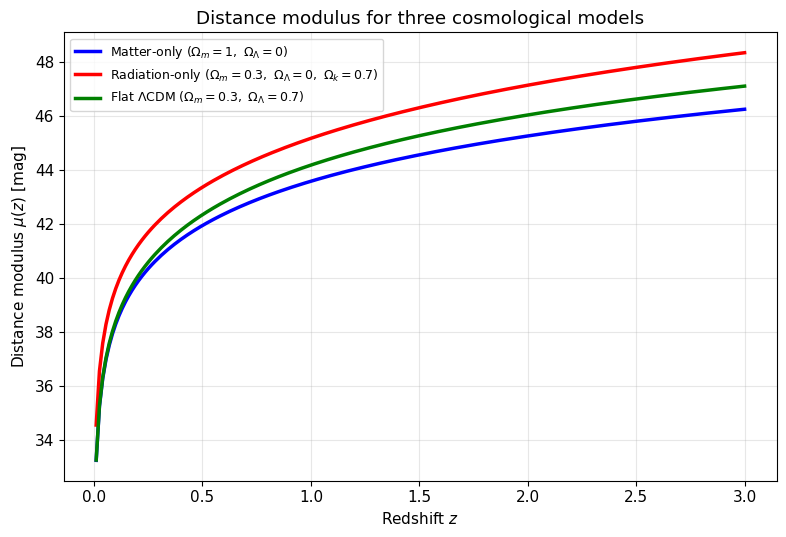

At fixed z, the LCDM model gives the largest distance modulus, because dark energy has caused extra acceleration/expansion compared to matter-dominated models. This extra dimming of Type Ia supernovae is precisely the 1998 discovery signature of cosmic acceleration.


In [45]:
#Defining spacing for smoothness
z_plot = np.linspace(0.01, 3, 200)

#Computing mu for each model
mu_matter = np.array([distance_modulus(z, 1.0, 0.0) for z in z_plot])
mu_open   = np.array([distance_modulus(z, 0.3, 0.0) for z in z_plot])
mu_LCDM   = np.array([distance_modulus(z, 0.3, 0.7) for z in z_plot])

#Plotting our collected data
fig, ax = plt.subplots(figsize=(8,5.5))
ax.plot(z_plot, mu_matter, color='b',   lw=2.5, label=r'Matter-only ($\Omega_m=1,\ \Omega_\Lambda=0$)')
ax.plot(z_plot, mu_open,   color='r',    lw=2.5, label=r'Radiation-only ($\Omega_m=0.3,\ \Omega_\Lambda=0,\ \Omega_k=0.7$)')
ax.plot(z_plot, mu_LCDM,   color='g',  lw=2.5, label=r'Flat $\Lambda$CDM ($\Omega_m=0.3,\ \Omega_\Lambda=0.7$)')

#Labeling and displaying plot
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'Distance modulus $\mu(z)$ [mag]')
ax.set_title('Distance modulus for three cosmological models')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("At fixed z, the LCDM model gives the largest distance modulus, because dark energy has caused extra acceleration/expansion compared"
      " to matter-dominated models. This extra dimming of Type Ia supernovae is precisely the 1998 discovery signature of cosmic acceleration.")

## 9. Parameter sweep over $\Omega_{m,0}$

Keeping $k=0$ so that $\Omega_{\Lambda,0}=1-\Omega_{m,0}$, we sweep
$\Omega_{m,0}\in\{0.1,0.2,\dots,1.0\}$ and examine:

The resulting family of expansion histories $a(t)$, the deceleration parameter today $q_0 = \frac{\Omega_{m,0}}{2} - \Omega_{\Lambda,0}$, the transition redshift $z_{\rm acc}$ at which the universe begins to accelerate and the age of the universe $t_0(\Omega_{m,0})$.

In [75]:
#Defining the sweep values
O_m_sweep = np.round(np.arange(0.1, 1.01, 0.1), 2)
O_l_sweep = 1 - O_m_sweep

#Initializing list
sweep_results = []
#Looping through each model and integrating 
for O_m, O_l in zip(O_m_sweep, O_l_sweep):
    t0_i = t0_LCDM(O_m, O_l) #Calling function for Lambda CDM model
    if O_l > 1e-9:
        t_i  = 1e-4 #Getting t close to 0
    else: 
        1e-6*t0_i #Getting t close to 0
    if O_l > 1e-9:
        a_i  = a_LCDM(t_i, O_m, O_l) #Calling function for Lambda CDM model
    else:
        a_matter(t_i, t0_i) #Calling function for matter-only model
    t_arr, a_arr, _ = solve_scale_factor(O_m, 0.0, O_l, a_i, t_i, 2.2*t0_i, n_dense=2000) #Calling function to retrieve (t, a)
    sweep_results.append((O_m, O_l, t0_i, t_arr, a_arr)) #Adds to the list

#Printing out the calculated sweep values
print("Om_m,0   Om_Lambda,0   t0 [Gyr]")
for O_m, O_l, t0_i, _, _ in sweep_results:
    print(f"  {O_m:.1f}        {O_l:.1f}       {t0_i:7.3f}")

Om_m,0   Om_Lambda,0   t0 [Gyr]
  0.1        0.9        18.551
  0.2        0.8        15.621
  0.3        0.7        13.996
  0.4        0.6        12.891
  0.5        0.5        12.063
  0.6        0.4        11.408
  0.7        0.3        10.869
  0.8        0.2        10.414
  0.9        0.1        10.022
  1.0        0.0         9.678


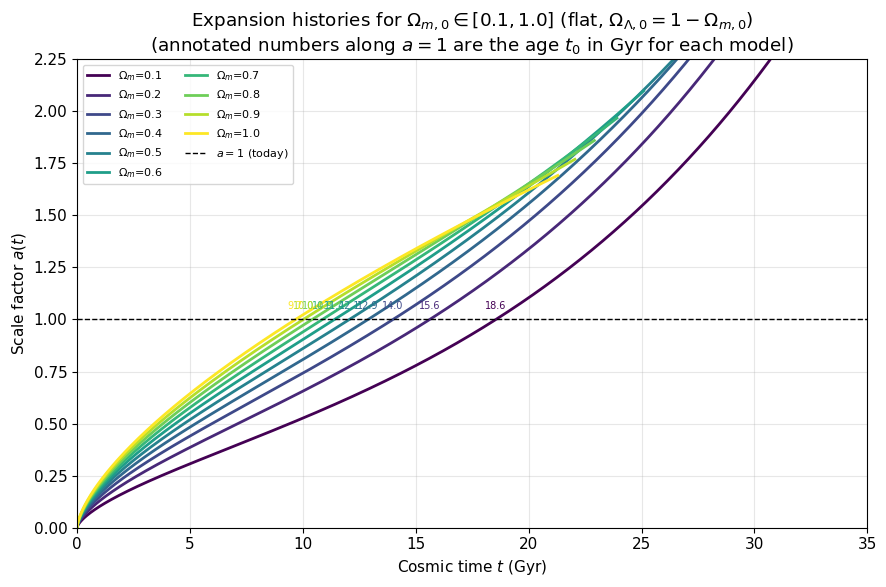

In [50]:
fig, ax = plt.subplots(figsize=(9,6))
#Defining coloring and spacing for smoothness
colors = plt.cm.viridis(np.linspace(0, 1, len(sweep_results)))

#Looping through each model and plotting respectively
for (O_m, O_l, t0_i, t_arr, a_arr), col in zip(sweep_results, colors):
    ax.plot(t_arr, a_arr, color=col, lw=2, label=f'$\\Omega_m$={O_m:.1f}')
    ax.annotate(f'{t0_i:.1f}', xy=(t0_i, 1.0), xytext=(t0_i, 1.05), fontsize=7, color=col, ha='center')

#Labeling and displaying plot
ax.axhline(1.0, color='k', ls='--', lw=1, label='$a=1$ (today)')
ax.set_xlabel('Cosmic time $t$ (Gyr)')
ax.set_ylabel('Scale factor $a(t)$')
ax.set_title(r'Expansion histories for $\Omega_{m,0}\in[0.1,1.0]$ (flat, $\Omega_{\Lambda,0}=1-\Omega_{m,0}$)'
             '\n(annotated numbers along $a=1$ are the age $t_0$ in Gyr for each model)')
ax.set_xlim(0, 35)
ax.set_ylim(0, 2.25)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

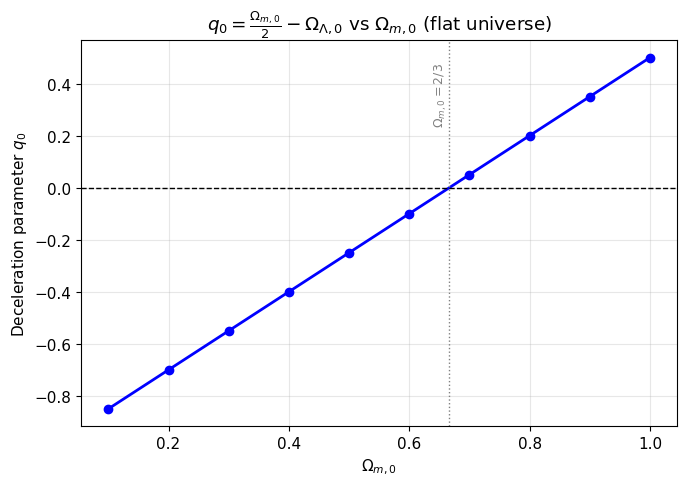

q0 < 0 (accelerating today) requires Omega_m,0 < 2/3. Meaning that Omega_Lambda,0 > 1/3.


In [76]:
#Deceleration vs matter density
#Defining the deceleration parameter
q0_sweep = 0.5*O_m_sweep - O_l_sweep

#Plotting our collected data
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(O_m_sweep, q0_sweep, 'o-', color='b', lw=2, ms=6)

#Labeling and displaying plot
ax.axhline(0, color='black', ls='--', lw=1)
ax.axvline(2/3, color='grey', ls=':', lw=1)
ax.text(2/3, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1]>0 else 0.1, r'$\Omega_{m,0}=2/3$', rotation=90, va='top', ha='right', fontsize=9, color='grey')
ax.set_xlabel(r'$\Omega_{m,0}$')
ax.set_ylabel(r'Deceleration parameter $q_0$')
ax.set_title(r'$q_0=\frac{\Omega_{m,0}}{2}-\Omega_{\Lambda,0}$ vs $\Omega_{m,0}$ (flat universe)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("q0 < 0 (accelerating today) requires Omega_m,0 < 2/3. Meaning that Omega_Lambda,0 > 1/3.")

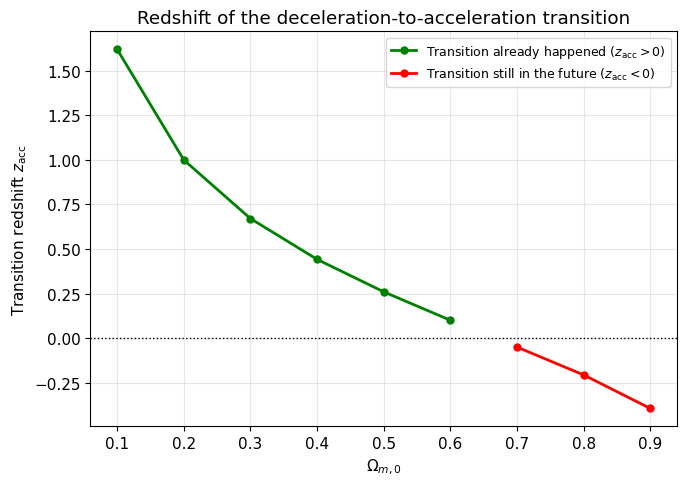

As Omega_m,0 increases, dark energy becomes sub-dominant at earlier times (lower z), so the transition to acceleration happens later, universe is still decelerating today and the transition (if any) lies in the future.


In [56]:
#Defining a function to find where the switch happens
def z_acc(O_m, O_l):
    if O_l <= 1e-12: #O_l -> 0 (never accelerates)
        return np.nan
    a_trans = (O_m/(2*O_l))**(1/3) #Derived using q=0 (when transition happens)
    return 1/a_trans - 1 #Returning z

#Initializing array by looping through each models pairs of data
zacc_sweep = np.array([z_acc(O_m, O_l) for O_m, O_l in zip(O_m_sweep, O_l_sweep)])

#Defining past and future split
past = zacc_sweep >= 0 #Bigger than current universe, thus has not happened yet (a<1)
future = zacc_sweep < 0 #Negative to flag it lies ahead of us in time (a>1)

#Plotting our collected data
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(O_m_sweep[past], zacc_sweep[past], 'o-', color='g', lw=2, ms=5, label='Transition already happened ($z_{\\rm acc}>0$)')
ax.plot(O_m_sweep[future], zacc_sweep[future], 'o-', color='r', lw=2, ms=5, label='Transition still in the future ($z_{\\rm acc}<0$)')

#Labeling and displaying plot
ax.axhline(0, color='k', ls=':', lw=1)
ax.set_xlabel(r'$\Omega_{m,0}$')
ax.set_ylabel(r'Transition redshift $z_{\rm acc}$')
ax.set_title('Redshift of the deceleration-to-acceleration transition')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("As Omega_m,0 increases, dark energy becomes sub-dominant at earlier times (lower z), so the transition to acceleration"
" happens later, universe is still decelerating today and the transition (if any) lies in the future.")

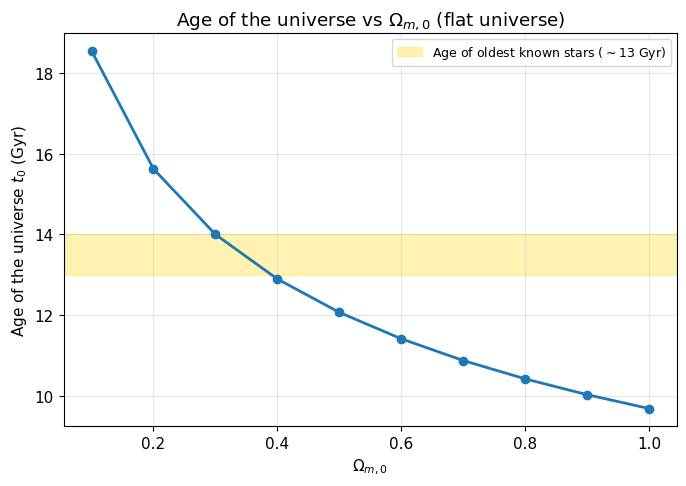

Models with Omega_m,0 < 0.3 give ages consistent with the oldest known stars (~13 Gyr), high-Omega_m,0 (matter-dominated) universes are too young, which historically was one of the strongest arguments for a non-zero Lambda.


In [57]:
#Initializing array with the ages under the Lambda CDM and matter-onlye model
t0_sweep = np.array([t0_LCDM(O_m, O_l) for O_m, O_l in zip(O_m_sweep, O_l_sweep)])

#Plotting our collected data
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(O_m_sweep, t0_sweep, 'o-', color='tab:blue', lw=2, ms=6)

#Labeling and displaying plot
ax.axhspan(13.0, 14.0, color='gold', alpha=0.3, label='Age of oldest known stars ($\\sim$13 Gyr)')
ax.set_xlabel(r'$\Omega_{m,0}$')
ax.set_ylabel(r'Age of the universe $t_0$ (Gyr)')
ax.set_title(r'Age of the universe vs $\Omega_{m,0}$ (flat universe)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

close_idx = np.argmin(np.abs(t0_sweep-13.5))
print(f"Models with Omega_m,0 < {O_m_sweep[close_idx]:.1f} give ages consistent with the oldest known stars (~13 Gyr), high-Omega_m,0"
" (matter-dominated) universes are too young, which historically was one of the strongest arguments for a non-zero Lambda.")

## 10. Cosmographic Taylor expansion check (Part 4.2)

For the fiducial flat $\Lambda$CDM model the exact cosmographic parameters follow from successive derivatives of $a(t)$ evaluated today:
$$q_0=\frac{\Omega_{m,0}}{2}-\Omega_{\Lambda,0}, \qquad j_0 = 1 \ \ (\text{identically, for any flat }\Lambda\text{CDM model}), \qquad
s_0 = 1-\frac{9}{2}\Omega_{m,0}.$$

We first confirm these numerically, by fitting a high-order spline to the numerically integrated $a(t)$ trajectory and differentiating it up to 4th order at $t=t_0$. We then compare the exact numerical $d_L(z)$ against the low-$z$ Taylor expansion and identify the redshift at which the expansion departs from the exact result by more than 1%.
$$d_L(z) = \frac{cz}{H_0}\left[1+\frac{1-q_0}{2}z - \frac{1-q_0-3q_0^2+j_0}{6}z^2 + O(z^3)\right]$$

In [72]:
#Extracting q0, j0, s0 from the numerically integrated Lambda CDM trajectory
spl = InterpolatedUnivariateSpline(t_L, a_L_num, k=5)   #Fit a smooth curve through the discrete points, then differentiate curve

#Getting the fitted data using spl
a_fit  = spl(t0_L)
da_fit = spl.derivative(1)(t0_L)
d2a_fit = spl.derivative(2)(t0_L)
d3a_fit = spl.derivative(3)(t0_L)
d4a_fit = spl.derivative(4)(t0_L)

#Defining our final numerical data
H_fit = da_fit/a_fit
q0_num = -d2a_fit/(a_fit*H_fit**2)
j0_num =  d3a_fit/(a_fit*H_fit**3)
s0_num =  d4a_fit/(a_fit*H_fit**4)

#Defining the analytical data (uses prior coding variables)
q0_an = O_m0/2 - O_l0
j0_an = 1.0
s0_an = 1 - 4.5*O_m0

#Printing our numerical vs analytical data
print(f"q0:  numerical = {q0_num:.6f}   analytic = {q0_an:.6f}")
print(f"j0:  numerical = {j0_num:.6f}   analytic = {j0_an:.6f}")
print(f"s0:  numerical = {s0_num:.6f}   analytic = {s0_an:.6f}")
print("\nj0 \u2248 1 identically for any flat LCDM model (independent of Omega_m,0), this is a distinctive, testable prediction"
" of the LCDM model against alternative dark-energy models, for which j0 generally deviates from unity.")

q0:  numerical = -0.550000   analytic = -0.550000
j0:  numerical = 1.000005   analytic = 1.000000
s0:  numerical = -0.377296   analytic = -0.350000

j0 ≈ 1 identically for any flat LCDM model (independent of Omega_m,0), this is a distinctive, testable prediction of the LCDM model against alternative dark-energy models, for which j0 generally deviates from unity.


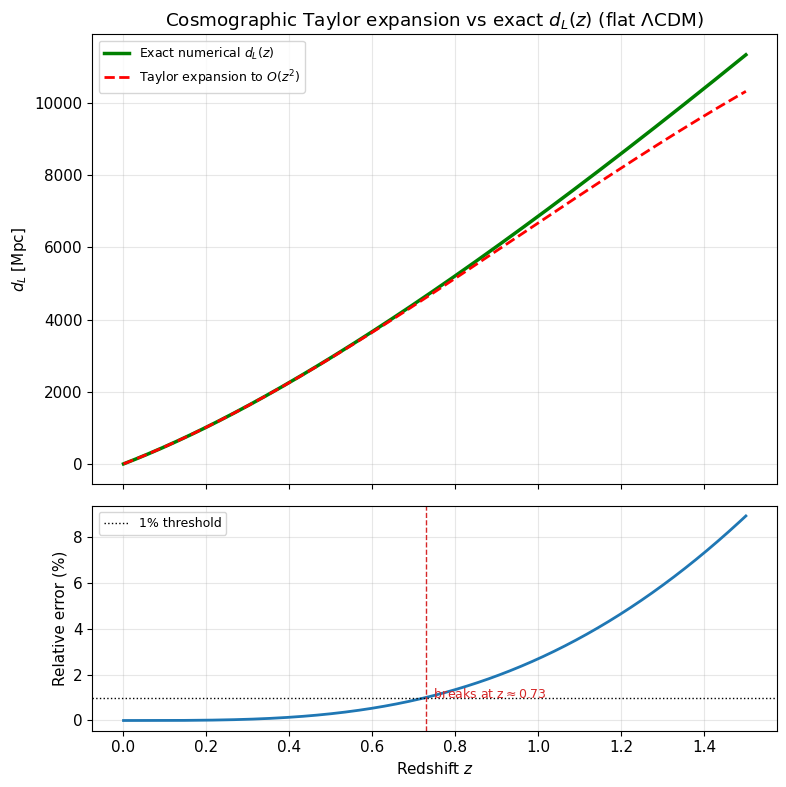

The second-order Taylor expansion of d_L(z) departs from the exact numerical result by more than 1% at z = 0.73


In [40]:
#Defining a function to test the Taylor expansion of d_L(z) (algebraic approximation)
def dL_taylor(z, q0, j0):
    return c_kms/H0_kmsMpc*z* (1 + 0.5*(1-q0)*z - (1 - q0 - 3*q0**2 + j0)/6 * z**2)

#Defining spacing for smoothness (setting start very close to 0)
z_cosmog = np.linspace(0.001, 1.5, 400)

#Defining an array to record the exact luminosity distance at each redshift
dL_num = np.array([luminosity_distance_Mpc(z, O_m0, O_l0) for z in z_cosmog])
dL_tay = dL_taylor(z_cosmog, q0_an, j0_an) #Calling our pure algebra function

#Calculating our relative percentage error
rel_err_pct = np.abs(dL_tay - dL_num)/dL_num * 100

#Finding the first redshift where the Taylor approximation percentage error > 1%
above = np.where(rel_err_pct > 1.0)[0]
if len(above):
    z_break = z_cosmog[above[0]]
else: 
    None

#Plotting our collected data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
ax1.plot(z_cosmog, dL_num, color='g', lw=2.5, label='Exact numerical $d_L(z)$')
ax1.plot(z_cosmog, dL_tay, color='r', lw=2, ls='--', label=r'Taylor expansion to $O(z^2)$')

#Labeling and displaying plot
ax1.set_ylabel('$d_L$ [Mpc]')
ax1.set_title(r'Cosmographic Taylor expansion vs exact $d_L(z)$ (flat $\Lambda$CDM)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

#Plotting our collected data
ax2.plot(z_cosmog, rel_err_pct, color='tab:blue', lw=2)

#Labeling and displaying plot
ax2.axhline(1.0, color='k', ls=':', lw=1, label='1% threshold')
if z_break is not None:
    ax2.axvline(z_break, color='tab:red', ls='--', lw=1)
    ax2.annotate(f'  breaks at z$\\approx${z_break:.2f}', xy=(z_break, 1.0), fontsize=9, color='tab:red')
ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel('Relative error (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The second-order Taylor expansion of d_L(z) departs from the exact numerical result by more than 1% at z = {z_break:.2f}")

## 11. Numerical precision check

The Friedmann equation implies
$$\mathcal{C}(t) \equiv \frac{H^2(t)}{H_0^2} - \left(\Omega_{m,0}a^{-3}+\Omega_{\Lambda,0}\right) = 0$$
at every point along a correctly integrated trajectory. We reconstruct $H(t)=\dot a/a$ from the numerical $a(t)$ solution using a spline derivative (independent of the ODE right-hand side, to check the integration), and plot $|\mathcal{C}(t)|$.

Right at the start of the integration $a\to0$ and $\dot a\to\infty$ (the Big-Bang singularity), so spline derivatives are unreliable in the first few sample points; we exclude a small buffer there, which is a normal, well-understood feature of the singularity and not a defect of the solver.

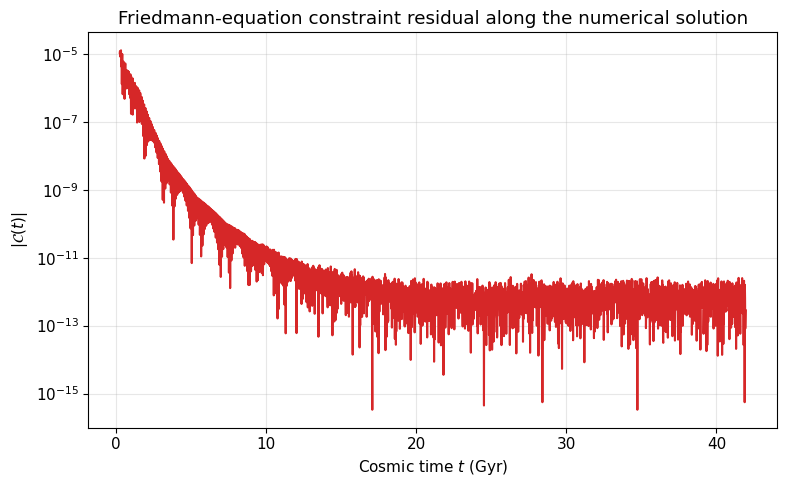

Median |C(t)| = 1.16e-12, Max |C(t)| (excluding boundary buffer) = 1.28e-05
The constraint is satisfied to within the expected floating-point/spline-differentiation noise floor across the whole integration range, confirming the solver is accurate.


In [74]:
spl_full = InterpolatedUnivariateSpline(t_L, a_L_num, k=5) #Fit a smooth curve through the discrete points, then differentiate curve
#Exclude findings near the Big-Bang singularity (t -> 0) where da/dt formally diverges and very end of integration 
#(spline derivatives become unreliable)
t_check = np.linspace(0.02*t0_L, t_L[-5], 3000)

#Getting the fitted data using spl_full
a_check = spl_full(t_check)
da_check = spl_full.derivative(1)(t_check)
H_check = da_check/a_check

#Defining the Friedmann equation (20)
C = (H_check/H0)**2 - E_squared(a_check, O_m0, 0.0, O_l0)

#Plotting our collected data
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(t_check, np.abs(C), color='tab:red', lw=1.5)

#Labeling and displaying plot
ax.set_yscale('log')
ax.set_xlabel('Cosmic time $t$ (Gyr)')
ax.set_ylabel(r'$|\mathcal{C}(t)|$')
ax.set_title('Friedmann-equation constraint residual along the numerical solution')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"Median |C(t)| = {np.median(np.abs(C)):.2e}, Max |C(t)| (excluding boundary buffer) = {np.max(np.abs(C)):.2e}")
print("The constraint is satisfied to within the expected floating-point/spline-differentiation noise floor across the whole"
" integration range, confirming the solver is accurate.")